# 电商次月复购预警

**目标：用过去三个完整自然月的 RFM，预测下一个自然月是否购买。**

标签 `NoPurchaseNextMonth=1` 表示次月没有有效购买，`0` 表示至少有一次有效购买，不表示永久流失。特征来自预测时已经可见的历史交易，标签来自之后完整一个月的购买记录。

本 Notebook 与命令行共用 `src/repurchase.py`。本地从项目目录打开，或者使用 Colab 链接打开后依次执行。

## 1. 找到代码并准备环境

Colab 会把本仓库克隆到当前运行环境，安装 requirements.txt。本地需先安装依赖。

In [1]:
from pathlib import Path
import sys
import subprocess

ROOT = Path.cwd()
if not (ROOT / 'src' / 'repurchase.py').exists():
    if (ROOT.parent / 'src' / 'repurchase.py').exists():
        ROOT = ROOT.parent
    else:
        ROOT = ROOT / 'customer-churn-warning'
        if not (ROOT / 'src' / 'repurchase.py').exists():
            subprocess.run(['git', 'clone', 'https://github.com/osnddwqd-hub/customer-churn-warning.git', str(ROOT)], check=True)
if 'google.colab' in sys.modules:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(ROOT / 'requirements.txt')], check=True)
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.repurchase import download_data, run_project, FEATURES, TARGET
print('Project:', ROOT)

Project: /workspace/scratch/56816236b5b5/customer-churn-warning


## 2. 读取原始数据并完整运行

数据来自 [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)，作者 Daqing Chen，2015，DOI: 10.24432/C5BW33，CC BY 4.0。范围是 2010-12-01 至 2011-12-09。下载后缓存，原始文件不提交。

流程：去重与有效购买清洗 → 月度 RFM → 未来标签 → 时间划分 → 训练与验证选参 → 冻结模型测试 → 独立重训部署模型 → 12 月无标签预测。首次执行需要下载并读取 Excel，请等待完成。

In [2]:
data_path = download_data(ROOT / 'data' / 'Online Retail.xlsx')
report = run_project(data_path)
print('Raw records:', report['raw_rows'])
print('Clean purchase lines:', report['clean_rows'])
print('Clean unique customers:', report['clean_unique_customers'])
print('Original file SHA256:', report['data_sha256'])

Raw records: 541909
Clean purchase lines: 392692
Clean unique customers: 4338
Original file SHA256: 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d


## 3. 看一条“用户 × 月份”样本

Cutoff 为被预测月份的月初零点。ObservationStart 到 Cutoff（不含 Cutoff）算特征，Cutoff 到 LabelEnd（不含 LabelEnd）算标签。Frequency 按不同订单号计数；Monetary 是有效正向消费总额，未扣除退款。

只有观察期买过东西的用户才纳入该月样本。新客户不能因为在未来第一次购买，就被提前纳入过去的人群。CustomerID 和日期不会作为模型输入。

In [3]:
samples = pd.read_csv(ROOT / 'output' / 'user_month_samples.csv', dtype={'CustomerID': str}, parse_dates=['Cutoff', 'ObservationStart', 'LabelEnd'])
display(samples.head(10))
print('User-month samples:', len(samples))
print('Input features:', FEATURES)
assert samples['Cutoff'].max() == pd.Timestamp('2011-11-01')
assert samples['LabelEnd'].max() == pd.Timestamp('2011-12-01')
assert not samples.duplicated(['CustomerID', 'Cutoff']).any()

,CustomerID,Cutoff,ObservationStart,Recency,Frequency,Monetary,NoPurchaseNextMonth,LabelEnd
0,12346,2011-03-01,2010-12-01,42,1,77183.60,1,2011-04-01
1,12347,2011-03-01,2010-12-01,34,2,1187.18,1,2011-04-01
2,12348,2011-03-01,2010-12-01,35,2,1120.24,1,2011-04-01
3,12350,2011-03-01,2010-12-01,27,1,334.40,1,2011-04-01
4,12352,2011-03-01,2010-12-01,13,1,296.50,0,2011-04-01
5,12356,2011-03-01,2010-12-01,42,1,2271.62,1,2011-04-01
6,12359,2011-03-01,2010-12-01,22,2,2386.41,1,2011-04-01
7,12361,2011-03-01,2010-12-01,4,1,189.90,1,2011-04-01
8,12362,2011-03-01,2010-12-01,12,1,479.10,1,2011-04-01
9,12365,2011-03-01,2010-12-01,8,2,641.38,1,2011-04-01


User-month samples: 17935
Input features: ['Recency', 'Frequency', 'Monetary']


## 4. 训练、验证、测试

预测 3–7 月的样本用于训练，8 月验证，9–11 月测试。训练标签在 8 月 1 日已成熟，验证标签在 9 月 1 日已成熟。

Pipeline: R、log1p(F)、log1p(M) → 训练集标准化 → LogisticRegression。只在验证集按 ROC-AUC 选择 C，按 F1 选择分类阈值。之后评估模型冻结，测试结果不反馈到参数选择。

In [4]:
display(pd.DataFrame(report['splits']))
display(pd.DataFrame(report['validation_candidates']))
print('Chosen C:', report['selected_C'])
print('Validation-selected threshold:', report['test_results']['rfm_logistic']['threshold'])

,split,prediction_months,rows,unique_customers,positive_rate
0,train,"[2011-03, 2011-04, 2011-05, 2011-06, 2011-07]",9316,2960,0.680228
1,validation,[2011-08],2030,2030,0.676355
2,test,"[2011-09, 2011-10, 2011-11]",6589,2991,0.609045


,C,validation_roc_auc,validation_average_precision
0,0.1,0.719303,0.809840
1,1.0,0.719221,0.809618
2,10.0,0.719215,0.809600


Chosen C: 0.1
Validation-selected threshold: 0.35000000000000003


## 5. 真实时间测试结果与基线

正类为次月未购买。比较 RFM 逻辑回归、仅 Recency 的逻辑回归和恒定先验概率。阈值分别在验证集选择。Average Precision 是 PR 曲线的汇总指标，不能与 ROC-AUC 混称。

低阈值的高召回伴随较多误报，需要同时看 Precision、混淆矩阵与触达比例。结合时间测试指标评价模型的区分能力与实际触达范围。

,rows,positive_rate,threshold,roc_auc,average_precision,accuracy,precision,recall,f1,brier_score
rfm_logistic,6589,0.609045,0.35,0.685089,0.736917,0.667021,0.651105,0.976576,0.7813,0.212837
recency_logistic,6589,0.609045,0.05,0.555348,0.657714,0.609045,0.609045,1.0,0.757027,0.240287
constant_prior,6589,0.609045,0.05,0.5,0.609045,0.609045,0.609045,1.0,0.757027,0.243176


,rows,positive_rate,threshold,roc_auc,average_precision,accuracy,precision,recall,f1,brier_score
2011-09,1948,0.62269,0.35,0.710732,0.768073,0.680698,0.666855,0.973619,0.791555,0.203006
2011-10,2161,0.63813,0.35,0.658027,0.742221,0.689958,0.679676,0.972444,0.800119,0.209766
2011-11,2480,0.572984,0.35,0.689974,0.711221,0.63629,0.614066,0.98311,0.755952,0.223237


Confusion matrix [actual purchase, actual no-purchase] rows: [[476, 2100], [94, 3919]]
Fraction predicted positive: 0.9134921839429352


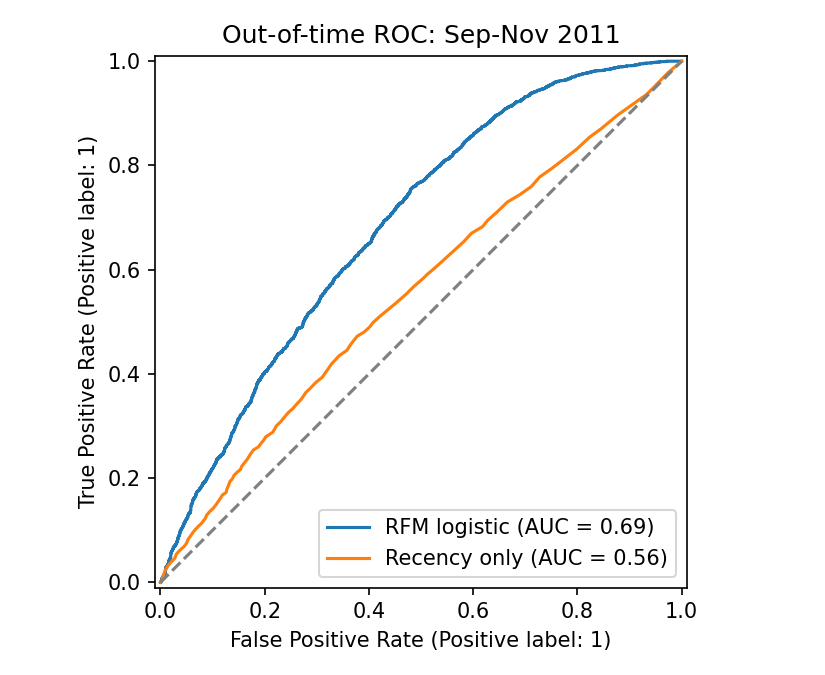

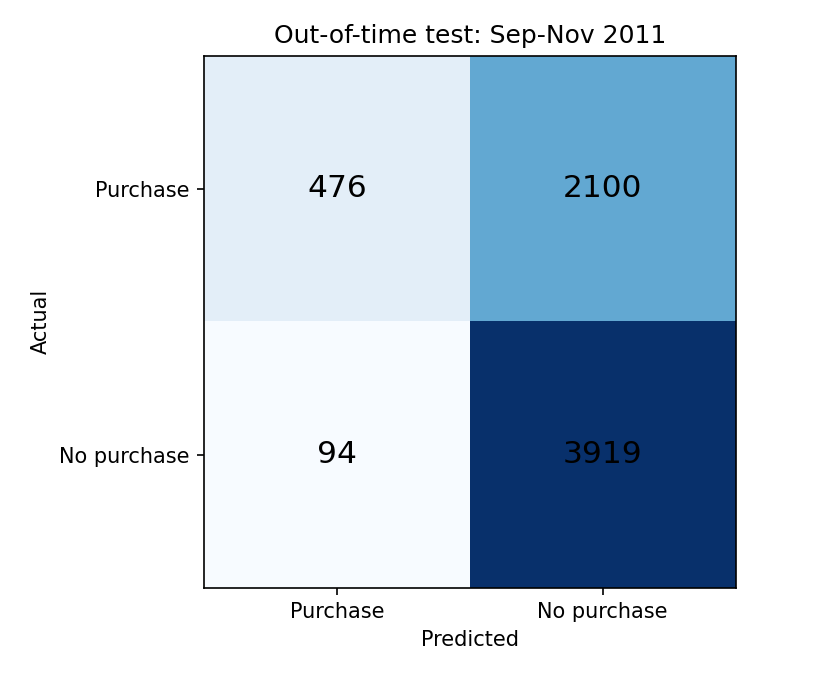

In [5]:
summary = pd.DataFrame(report['test_results']).T
metrics = ['rows', 'positive_rate', 'threshold', 'roc_auc', 'average_precision', 'accuracy', 'precision', 'recall', 'f1', 'brier_score']
display(summary[metrics])
display(pd.DataFrame(report['test_results_by_month']).T[metrics])
cm = report['test_results']['rfm_logistic']['confusion_matrix']
print('Confusion matrix [actual purchase, actual no-purchase] rows:', cm)
print('Fraction predicted positive:', (cm[0][1] + cm[1][1]) / sum(map(sum, cm)))
display(Image(filename=str(ROOT / 'images' / 'roc_curve.png')))
display(Image(filename=str(ROOT / 'images' / 'confusion_matrix.png')))

## 6. 每月固定选风险最高的 20%

按每个月分别排序，示例预算在测试前固定为 20%。Lift 是相对于随机选人的未购买识别提升，不是营销转化或留存收益。高风险客户是否能被发券挽回，需要另做实验。

In [6]:
monthly = pd.read_csv(ROOT / 'output' / 'monthly_top20_metrics.csv')
display(monthly)

,month,eligible_customers,contact_budget,positive_rate,precision_at_20pct,recall_at_20pct,lift_at_20pct
0,2011-09,1948,390,0.622690,0.810256,0.260511,1.301220
1,2011-10,2161,433,0.638130,0.741339,0.232777,1.161737
2,2011-11,2480,496,0.572984,0.739919,0.258269,1.291344


## 7. 系数解释

以下是冻结评估模型的标准化系数，对应“其他特征固定时”的条件关联。Frequency、Monetary 转换过，不能按原始金额单位解释。系数不是因果效应。

本次 Recency 系数略为负，因此不能简单解释为“越久不买一定越危险”。特征相关性、人群筛选和季节性都可能影响系数，不能从这一个模型确定原因。

,feature,standardized_coefficient
0,Recency,-0.105793
1,log1p(Frequency),-0.767057
2,log1p(Monetary),-0.280372


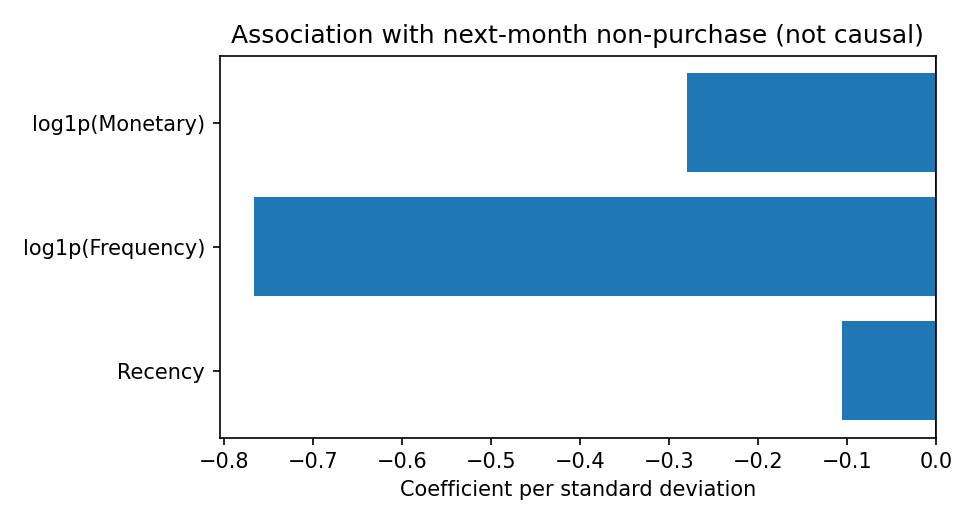

In [7]:
display(pd.read_csv(ROOT / 'output' / 'coefficients.csv'))
display(Image(filename=str(ROOT / 'images' / 'feature_importance.png')))

## 8. 当时可执行的 12 月预测

在 2011-12-01，3–11 月的标签已经完整可见。沿用验证选定的 C，在这些历史样本上**单独重训部署模型**，用 9–11 月特征预测 12 月。

该部署模型与上面的冻结测试模型不同。12 月数据只到 9 日，不生成 12 月真实标签、不评价 12 月准确率。此名单是 2011 年的模拟业务输出。模型估计概率尚未单独校准，优先用作风险排序。

In [8]:
high_risk = pd.read_csv(ROOT / 'output' / 'high_risk_users.csv', dtype={'CustomerID': str})
display(high_risk.head(10))
print('Eligible customers:', report['forecast_eligible_customers'])
print('Top 20% candidates:', len(high_risk))
print('Status:', report['forecast_status'])
assert TARGET not in high_risk.columns
assert high_risk['NoPurchaseProbability'].between(0, 1).all()
assert high_risk['NoPurchaseProbability'].is_monotonic_decreasing

,CustomerID,Cutoff,ObservationStart,Recency,Frequency,Monetary,PredictionMonth,NoPurchaseProbability
0,15764,2011-12-01,2011-09-01,80,1,3.350,2011-12,0.894974
1,14792,2011-12-01,2011-09-01,55,1,6.200,2011-12,0.891882
2,12843,2011-12-01,2011-09-01,57,1,9.950,2011-12,0.880682
3,16953,2011-12-01,2011-09-01,22,1,20.800,2011-12,0.876276
4,16852,2011-12-01,2011-09-01,2,1,31.850,2011-12,0.873243
5,15657,2011-12-01,2011-09-01,14,1,30.000,2011-12,0.869890
6,16856,2011-12-01,2011-09-01,6,1,35.400,2011-12,0.868728
7,13606,2011-12-01,2011-09-01,21,1,30.120,2011-12,0.866826
8,13405,2011-12-01,2011-09-01,66,1,15.001,2011-12,0.866660
9,16878,2011-12-01,2011-09-01,76,1,13.300,2011-12,0.865606


Eligible customers: 2851
Top 20% candidates: 571
Status: unlabeled forecast; incomplete December cannot be evaluated


## 9. 可以复述的结论

项目使用过去三个完整自然月的 RFM 预测下一个自然月是否购买，按时间划分训练、验证和测试。RFM 基线有一定区分能力，但训练与测试月份的行为分布有差异，整体效果仍有限。次月不买不等于永久流失，识别风险也不等于证明营销有效。

详见 README、`docs/methodology.md` 与 `tests/test_repurchase.py`。测试覆盖未来交易修改不影响历史特征、完整标签窗口、订单口径、时间边界、标签成熟和仅用训练集拟合标准化。